# Plotting for Project 2

In [68]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from colormaps import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
np.random.seed(27)

# x0_map = {
#     "Simple1": np.array([[-2,2], [1, -2], [1.5, 1]]),
#     "Simple2": np.array([[2,2], [-1, -1], [3, 3]]),
#     "Simple3": np.array([[1,1,1], [-1, -3, -1], [2, 2, 1]]),
# }
# 10 random initializations in the range [-3, 3]
n_samples = 4
x0_map = {
    "Simple1": np.round(np.random.uniform(-3, 3, (n_samples, 2)), 2),
    "Simple2": np.round(np.random.uniform(-3, 3, (n_samples, 2)), 2),
    "Simple3": np.round(np.random.uniform(-3, 3, (n_samples, 3)), 2),
}

x_best_map = {
    "Simple1": np.array([2/3, 1/np.sqrt(3)]),
    "Simple2": np.array([1,1]),
    "Simple3": np.array([-1/np.sqrt(6), np.sqrt(2/3), -1/np.sqrt(6)]),
}

## Quadratic penalty L-BFGS

In [70]:
from project2_py.helpers import Simple1, Simple2, Simple3
from project2_py.project2 import *

x_hists = {}
f_pen_hists = {}
f_hists = {}
pen_f_hists = {}
g_pen_hists = {}
g_hists = {}
pen_g_hists = {}
c_max_vio_hists = {}

for p_name in [Simple1, Simple2, Simple3]:
    for x0 in x0_map[p_name.__name__]:
        p = p_name()
        if p_name.__name__ == "Simple1":
            key = "simple1"
        if p_name.__name__ == "Simple2":
            key = "simple2"
        if p_name.__name__ == "Simple3":
            key = "simple3"
        x_history, f_pen_history, f_history, pen_f_history, g_pen_history, g_history, pen_g_history = penalty_l_bfgs(p.f, p.g, p.c, x0, 2000, p.count, strategy_config_map[key]['quadratic_penalty_l_bfgs'], penalty_mode='quadratic')

        # store histories for plotting
        x_hists[(p_name.__name__, tuple(x0))] = x_history
        f_pen_hists[(p_name.__name__, tuple(x0))] = f_pen_history
        f_hists[(p_name.__name__, tuple(x0))] = f_history
        pen_f_hists[(p_name.__name__, tuple(x0))] = pen_f_history
        g_pen_hists[(p_name.__name__, tuple(x0))] = g_pen_history
        g_hists[(p_name.__name__, tuple(x0))] = g_history
        pen_g_hists[(p_name.__name__, tuple(x0))] = pen_g_history

        # print
        print(f"Problem: {p_name.__name__}, x0: {x0}, x_best: {x_history[-1]}, f(x_best): {p.f(x_history[-1])}, c(x_best): {p.c(x_history[-1])}")

Problem: Simple1, x0: [-1.71 -2.56], x_best: [0.0553487  0.53923468], f(x_best): 0.35505424070112324, c(x_best): [-0.65387726 -0.59458338]
Problem: Simple1, x0: [-2.54 -1.21], x_best: [0.01449104 0.62605624], f(x_best): 0.3758279750419117, c(x_best): [-0.59356254 -0.64054728]
Problem: Simple1, x0: [-2.22 -0.82], x_best: [0.1756003  0.90172369], f(x_best): 0.2265572251280892, c(x_best): [-0.01129408 -1.077324  ]
Problem: Simple1, x0: [1.23 2.28], x_best: [0.78096424 0.4681699 ], f(x_best): 0.019276225681964354, c(x_best): [ 1.47301066e-04 -1.24913415e+00]
Problem: Simple2, x0: [-2.99  0.8 ], x_best: [0.99999986 0.99999997], f(x_best): 6.347307795989375e-12, c(x_best): [ 2.55349797e-08 -1.64081181e-07]
Problem: Simple2, x0: [-2.82  2.84], x_best: [-2.05945826  4.05920504], f(x_best): 12.678631805944587, c(x_best): [-3.16966059e+01 -2.53228252e-04]
Problem: Simple2, x0: [1.38 2.22], x_best: [0.0013744  0.00334315], f(x_best): 0.9983694895287646, c(x_best): [ 7.74388618e-04 -1.99528245e+00

### Contour plot with feasible region for Simple1

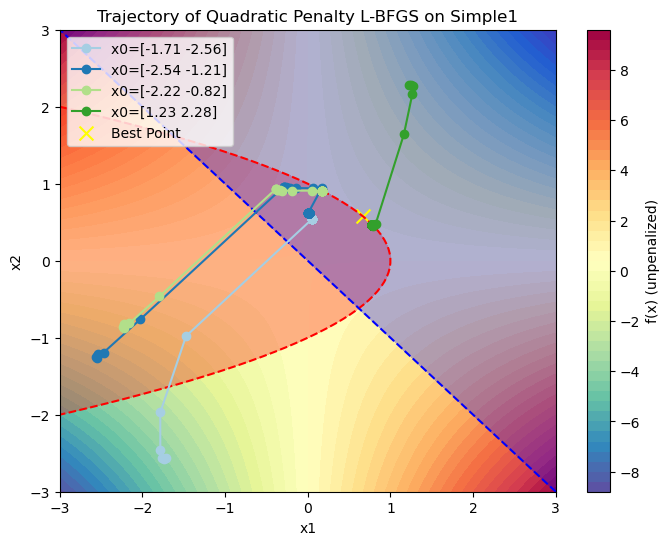

In [71]:
# heatmap of f for Simple1
p = Simple1()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Quadratic Penalty L-BFGS on Simple1')

# constraints
c1 = X1 + X2**2 - 1
c2 = -X1 - X2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple1"]:
    x_hist = x_hists[("Simple1", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple1"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Contour plot with feasible region for Simple2

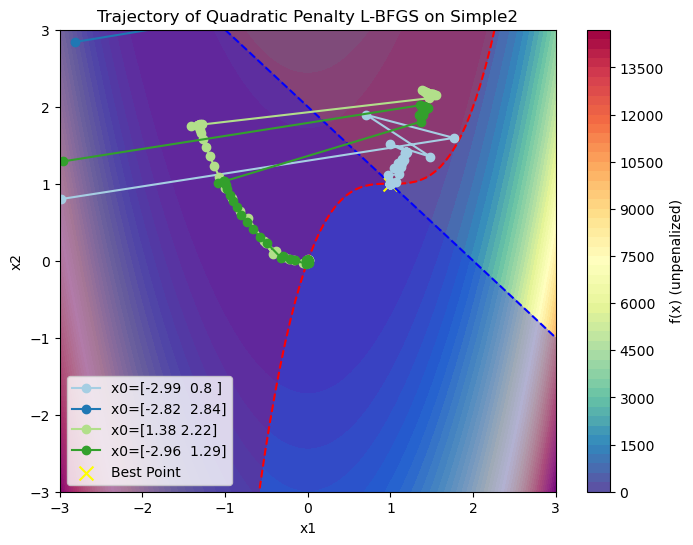

In [72]:
# heatmap of f for Simple2
p = Simple2()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Quadratic Penalty L-BFGS on Simple2')

# constraints
c1 = (X1-1)**3 - X2 + 1
c2 = X1 + X2 -2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple2"]:
    x_hist = x_hists[("Simple2", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple2"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Objective function and maximum constraint violation vs iteration for Simple2

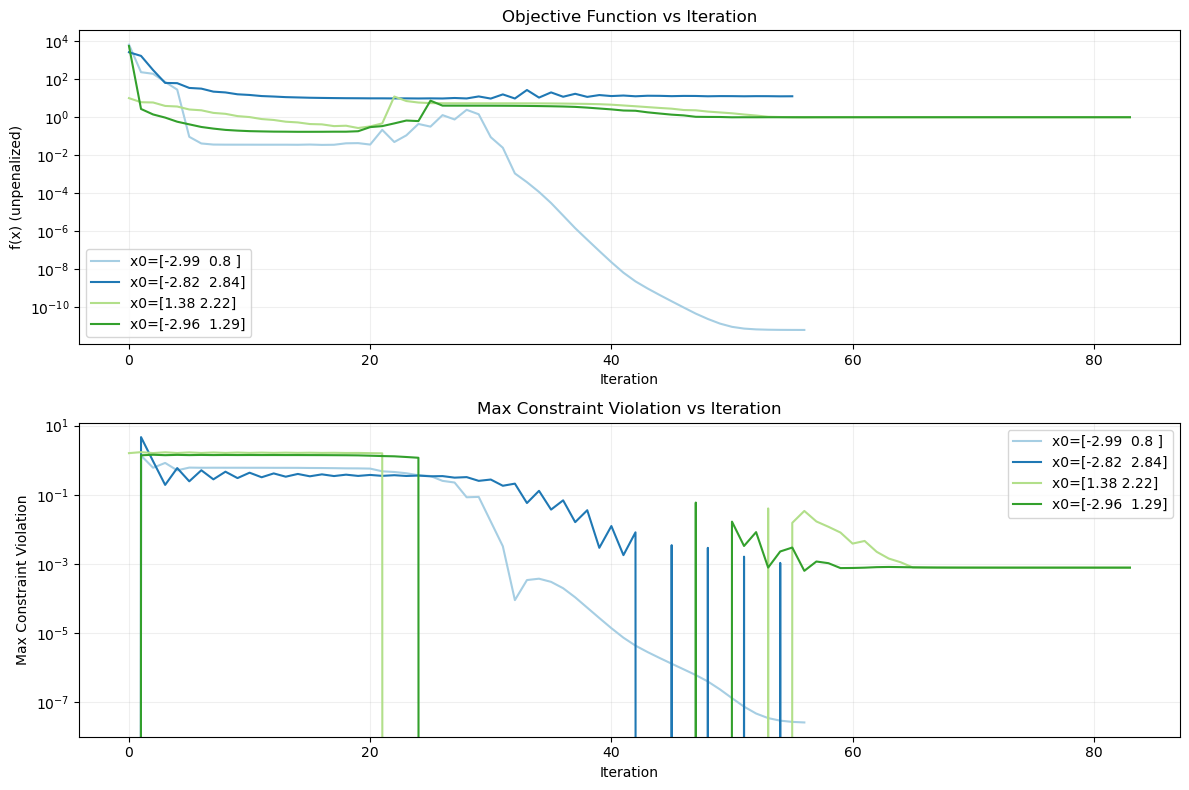

In [73]:
# plot objective function and maximum constraint violation vs iteration for Simple2
plt.figure(figsize=(12, 8))
for i, x0 in enumerate(x0_map["Simple2"]):
    f_history = f_hists[("Simple2", tuple(x0))]

    # plot convergence
    plt.subplot(2,1,1)
    plt.plot(f_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('f(x) (unpenalized)')
    plt.title('Objective Function vs Iteration')
    plt.grid(True, alpha=0.2)
    plt.legend(loc = "best")

    # plot maximum constraint violation
    # get constraint violation history
    c_history = []
    for x in x_hists[("Simple2", tuple(x0))]:
        c1 = (x[0]-1)**3 - x[1] + 1
        c2 = x[0] + x[1] -2
        c_history.append(max(0, max(c1, c2)))
    plt.subplot(2, 1, 2)
    plt.plot(c_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Max Constraint Violation')
    plt.title('Max Constraint Violation vs Iteration')
    plt.legend(loc = "best")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    

## Quadratic penalty gradient descent

In [74]:
from project2_py.helpers import Simple1, Simple2, Simple3
from project2_py.project2 import *

x_hists = {}
f_pen_hists = {}
f_hists = {}
pen_f_hists = {}

for p_name in [Simple1, Simple2, Simple3]:
    for x0 in x0_map[p_name.__name__]:
        p = p_name()
        if p_name.__name__ == "Simple1":
            key = "simple1"
        if p_name.__name__ == "Simple2":
            key = "simple2"
        if p_name.__name__ == "Simple3":
            key = "simple3"
        x_history, f_pen_history, f_history, pen_f_history = penalty_gradient_descent(p.f, p.g, p.c, x0, 2000, p.count, strategy_config_map[key]['quadratic_penalty_gradient_descent'], penalty_mode='quadratic')

        # store histories for plotting
        x_hists[(p_name.__name__, tuple(x0))] = x_history
        f_pen_hists[(p_name.__name__, tuple(x0))] = f_pen_history
        f_hists[(p_name.__name__, tuple(x0))] = f_history
        pen_f_hists[(p_name.__name__, tuple(x0))] = pen_f_history
        g_pen_hists[(p_name.__name__, tuple(x0))] = g_pen_history
        g_hists[(p_name.__name__, tuple(x0))] = g_history
        pen_g_hists[(p_name.__name__, tuple(x0))] = pen_g_history

        # print
        print(f"Problem: {p_name.__name__}, x0: {x0}, x_best: {x_history[-1]}, f(x_best): {p.f(x_history[-1])}, c(x_best): {p.c(x_history[-1])}")

Problem: Simple1, x0: [-1.71 -2.56], x_best: [0.74868738 0.50186116], f(x_best): 0.009163064358364281, c(x_best): [ 5.52000220e-04 -1.25054854e+00]
Problem: Simple1, x0: [-2.54 -1.21], x_best: [0.75540593 0.49528851], f(x_best): 0.01075630148323542, c(x_best): [ 7.16638309e-04 -1.25069444e+00]
Problem: Simple1, x0: [-2.22 -0.82], x_best: [0.55677201 0.66613137], f(x_best): 0.014016876156210223, c(x_best): [ 5.03014069e-04 -1.22290338e+00]
Problem: Simple1, x0: [1.23 2.28], x_best: [0.55829244 0.66476047], f(x_best): 0.01376943461735114, c(x_best): [ 1.98921043e-04 -1.22305291e+00]
Problem: Simple2, x0: [-2.99  0.8 ], x_best: [0.9999999  1.00000005], f(x_best): 6.620867291387334e-12, c(x_best): [-5.11915679e-08 -5.17648537e-08]
Problem: Simple2, x0: [-2.82  2.84], x_best: [-1.8809228   3.54807761], f(x_best): 8.310134529100928, c(x_best): [-26.45891909  -0.33284519]
Problem: Simple2, x0: [1.38 2.22], x_best: [-1.29445129  1.67688052], f(x_best): 5.264669635986495, c(x_best): [-12.756034

### Contour plot with feasible region for Simple1

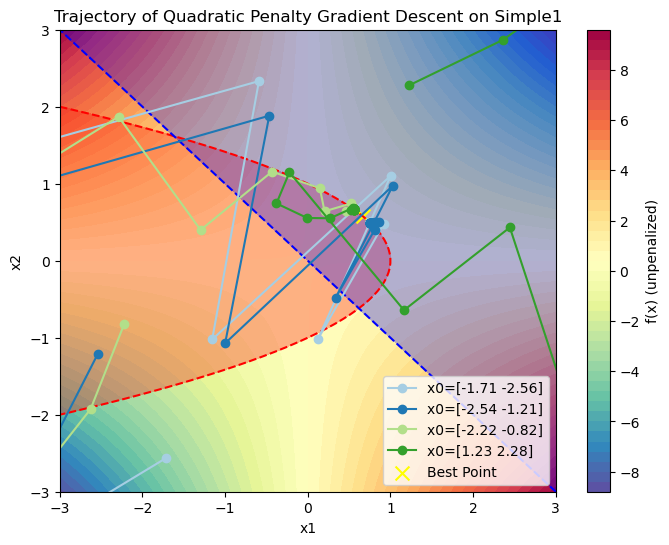

In [75]:
# heatmap of f for Simple1
p = Simple1()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Quadratic Penalty Gradient Descent on Simple1')

# constraints
c1 = X1 + X2**2 - 1
c2 = -X1 - X2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple1"]:
    x_hist = x_hists[("Simple1", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple1"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Contour plot with feasible region for Simple2

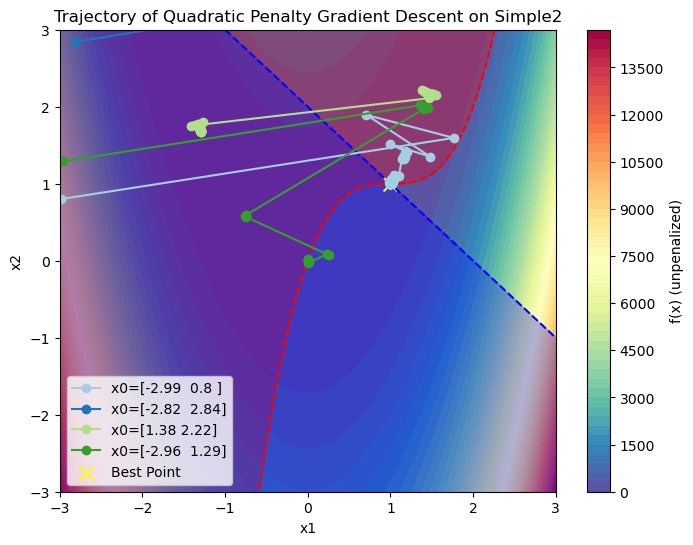

In [76]:
# heatmap of f for Simple2
p = Simple2()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Quadratic Penalty Gradient Descent on Simple2')

# constraints
c1 = (X1-1)**3 - X2 + 1
c2 = X1 + X2 -2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple2"]:
    x_hist = x_hists[("Simple2", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple2"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Objective function and maximum constraint violation vs iteration for Simple2

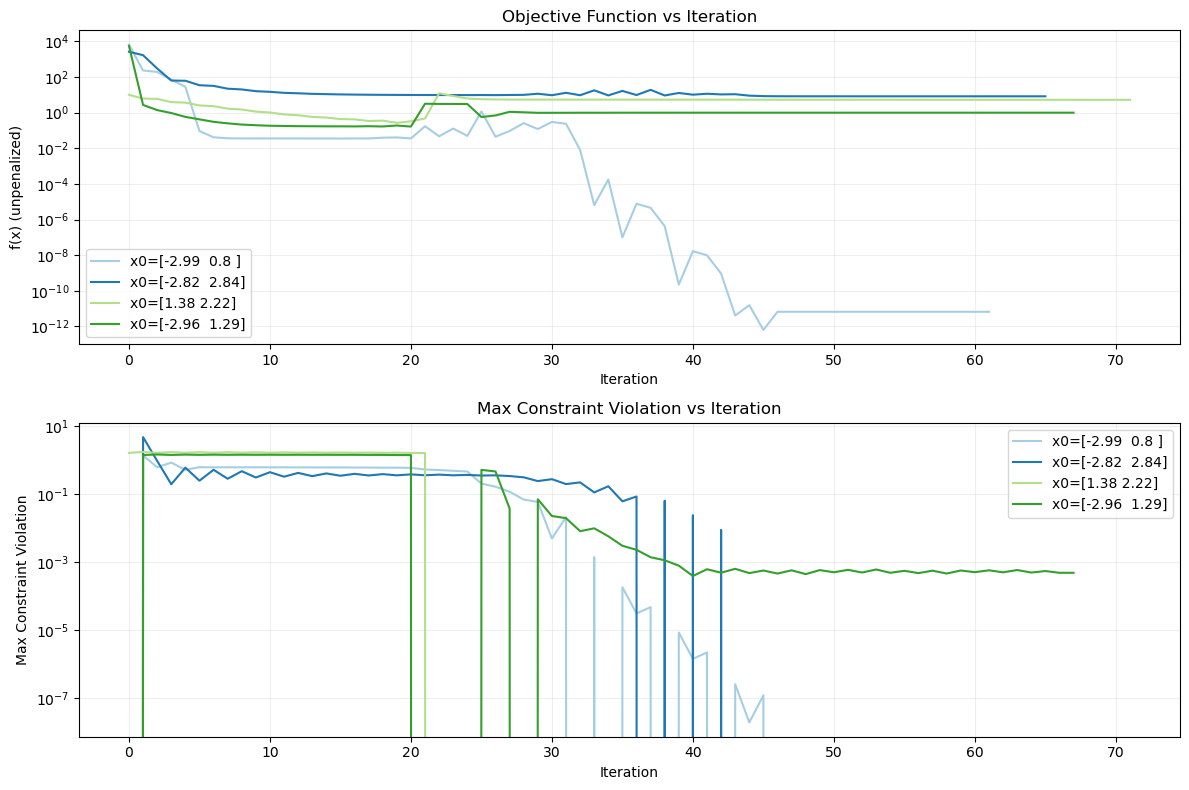

In [77]:
# plot objective function and maximum constraint violation vs iteration for Simple2
plt.figure(figsize=(12, 8))
for i, x0 in enumerate(x0_map["Simple2"]):
    f_history = f_hists[("Simple2", tuple(x0))]

    # plot convergence
    plt.subplot(2,1,1)
    plt.plot(f_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('f(x) (unpenalized)')
    plt.title('Objective Function vs Iteration')
    plt.grid(True, alpha=0.2)
    plt.legend(loc = "best")

    # plot maximum constraint violation
    # get constraint violation history
    c_history = []
    for x in x_hists[("Simple2", tuple(x0))]:
        c1 = (x[0]-1)**3 - x[1] + 1
        c2 = x[0] + x[1] -2
        c_history.append(max(0, max(c1, c2)))
    plt.subplot(2, 1, 2)
    plt.plot(c_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Max Constraint Violation')
    plt.title('Max Constraint Violation vs Iteration')
    plt.legend(loc = "best")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    

## Absolute penalty L-BFGS

In [78]:
from project2_py.helpers import Simple1, Simple2, Simple3
from project2_py.project2 import *

x_hists = {}
f_pen_hists = {}
f_hists = {}
pen_f_hists = {}
g_pen_hists = {}
g_hists = {}
pen_g_hists = {}
c_max_vio_hists = {}

for p_name in [Simple1, Simple2, Simple3]:
    for x0 in x0_map[p_name.__name__]:
        p = p_name()
        if p_name.__name__ == "Simple1":
            key = "simple1"
        if p_name.__name__ == "Simple2":
            key = "simple2"
        if p_name.__name__ == "Simple3":
            key = "simple3"
        x_history, f_pen_history, f_history, pen_f_history, g_pen_history, g_history, pen_g_history = penalty_l_bfgs(p.f, p.g, p.c, x0, 2000, p.count, strategy_config_map[key]['absolute_penalty_l_bfgs'], penalty_mode='absolute')

        # store histories for plotting
        x_hists[(p_name.__name__, tuple(x0))] = x_history
        f_pen_hists[(p_name.__name__, tuple(x0))] = f_pen_history
        f_hists[(p_name.__name__, tuple(x0))] = f_history
        pen_f_hists[(p_name.__name__, tuple(x0))] = pen_f_history
        g_pen_hists[(p_name.__name__, tuple(x0))] = g_pen_history
        g_hists[(p_name.__name__, tuple(x0))] = g_history
        pen_g_hists[(p_name.__name__, tuple(x0))] = pen_g_history

        # print
        print(f"Problem: {p_name.__name__}, x0: {x0}, x_best: {x_history[-1]}, f(x_best): {p.f(x_history[-1])}, c(x_best): {p.c(x_history[-1])}")

Problem: Simple1, x0: [-1.71 -2.56], x_best: [-0.00851959  1.00431599], f(x_best): 0.3934565423664831, c(x_best): [ 1.31021524e-04 -9.95796401e-01]
Problem: Simple1, x0: [-2.54 -1.21], x_best: [-0.18199899  1.06855729], f(x_best): 0.5793765239545032, c(x_best): [-0.0401843  -0.88655831]
Problem: Simple1, x0: [-2.22 -0.82], x_best: [0.04871405 0.94111523], f(x_best): 0.33905464120963735, c(x_best): [-0.06558808 -0.98982928]
Problem: Simple1, x0: [1.23 2.28], x_best: [0. 0.], f(x_best): 0.3849001794597505, c(x_best): [-1. -0.]
Problem: Simple2, x0: [-2.99  0.8 ], x_best: [0.96466915 0.9964594 ], f(x_best): 0.43517127806149597, c(x_best): [ 0.0034965  -0.03887146]
Problem: Simple2, x0: [-2.82  2.84], x_best: [-2.02637996  4.03354618], f(x_best): 9.687062201119579, c(x_best): [-3.07520866e+01  7.16621913e-03]
Problem: Simple2, x0: [1.38 2.22], x_best: [0.00264241 0.00750392], f(x_best): 1.0003425642493282, c(x_best): [ 4.02384451e-04 -1.98985367e+00]
Problem: Simple2, x0: [-2.96  1.29], x_

### Contour plot with feasible region for Simple1

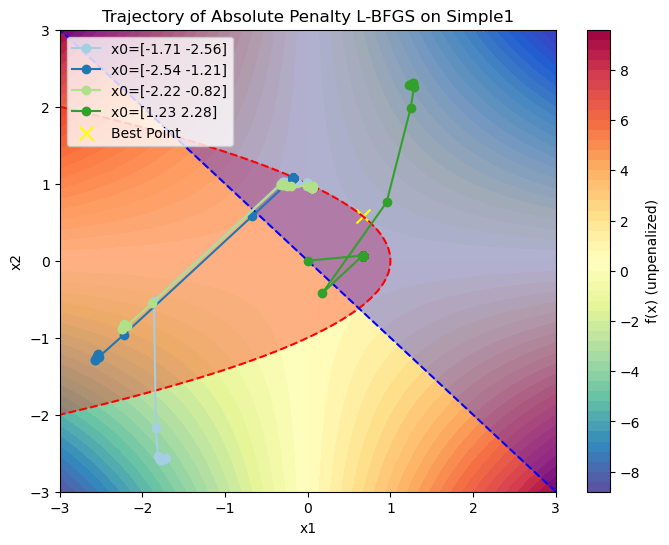

In [79]:
# heatmap of f for Simple1
p = Simple1()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Absolute Penalty L-BFGS on Simple1')

# constraints
c1 = X1 + X2**2 - 1
c2 = -X1 - X2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple1"]:
    x_hist = x_hists[("Simple1", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple1"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Contour plot with feasible region for Simple2

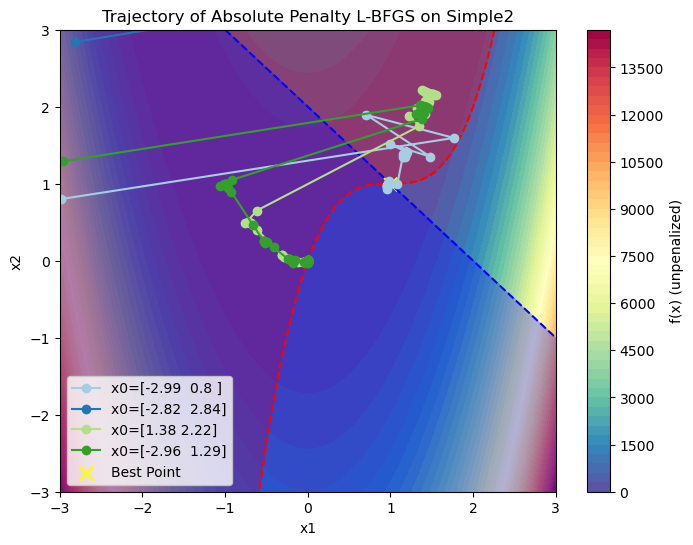

In [80]:
# heatmap of f for Simple2
p = Simple2()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Absolute Penalty L-BFGS on Simple2')

# constraints
c1 = (X1-1)**3 - X2 + 1
c2 = X1 + X2 -2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple2"]:
    x_hist = x_hists[("Simple2", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple2"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Objective function and maximum constraint violation vs iteration for Simple2

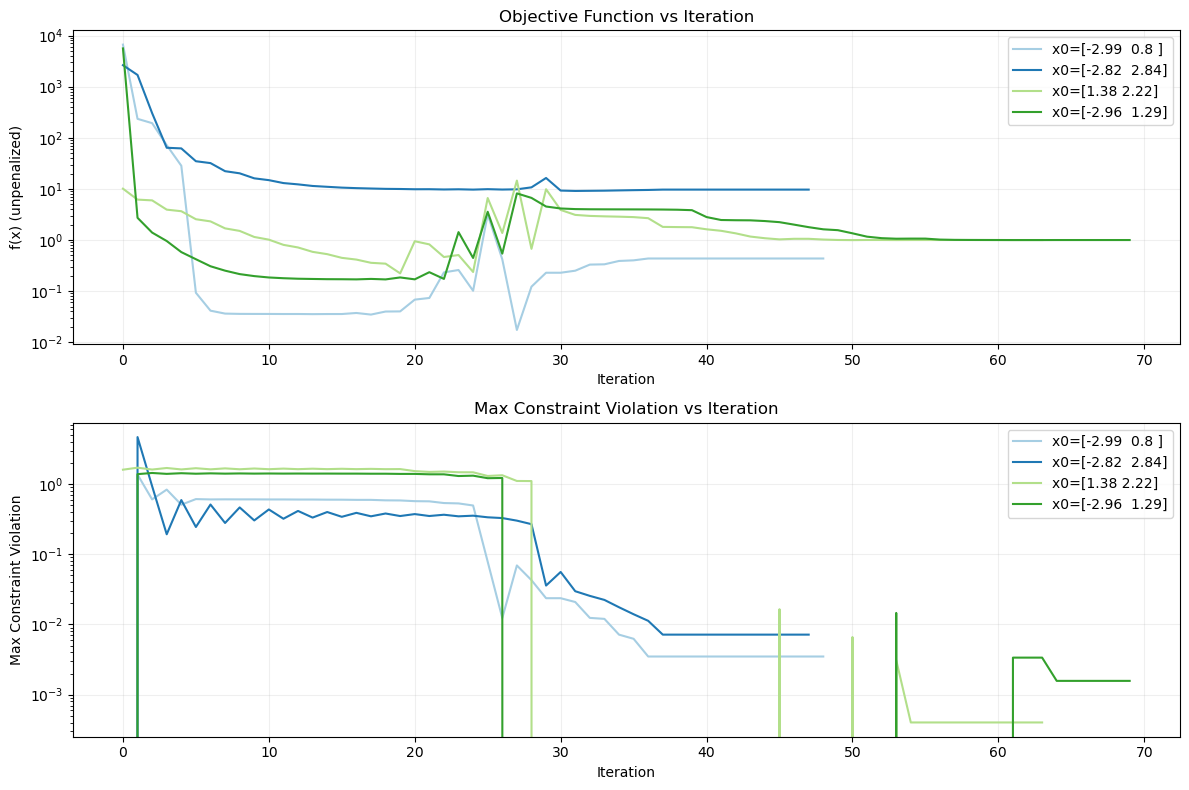

In [81]:
# plot objective function and maximum constraint violation vs iteration for Simple2
plt.figure(figsize=(12, 8))
for i, x0 in enumerate(x0_map["Simple2"]):
    f_history = f_hists[("Simple2", tuple(x0))]

    # plot convergence
    plt.subplot(2,1,1)
    plt.plot(f_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('f(x) (unpenalized)')
    plt.title('Objective Function vs Iteration')
    plt.grid(True, alpha=0.2)
    plt.legend(loc = "best")

    # plot maximum constraint violation
    # get constraint violation history
    c_history = []
    for x in x_hists[("Simple2", tuple(x0))]:
        c1 = (x[0]-1)**3 - x[1] + 1
        c2 = x[0] + x[1] -2
        c_history.append(max(0, max(c1, c2)))
    plt.subplot(2, 1, 2)
    plt.plot(c_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Max Constraint Violation')
    plt.title('Max Constraint Violation vs Iteration')
    plt.legend(loc = "best")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    

## Absolute penalty gradient descent

In [82]:
from project2_py.helpers import Simple1, Simple2, Simple3
from project2_py.project2 import *

x_hists = {}
f_pen_hists = {}
f_hists = {}
pen_f_hists = {}

for p_name in [Simple1, Simple2, Simple3]:
    for x0 in x0_map[p_name.__name__]:
        p = p_name()
        if p_name.__name__ == "Simple1":
            key = "simple1"
        if p_name.__name__ == "Simple2":
            key = "simple2"
        if p_name.__name__ == "Simple3":
            key = "simple3"
        x_history, f_pen_history, f_history, pen_f_history = penalty_gradient_descent(p.f, p.g, p.c, x0, 2000, p.count, strategy_config_map[key]['absolute_penalty_gradient_descent'], penalty_mode='absolute')

        # store histories for plotting
        x_hists[(p_name.__name__, tuple(x0))] = x_history
        f_pen_hists[(p_name.__name__, tuple(x0))] = f_pen_history
        f_hists[(p_name.__name__, tuple(x0))] = f_history
        pen_f_hists[(p_name.__name__, tuple(x0))] = pen_f_history
        g_pen_hists[(p_name.__name__, tuple(x0))] = g_pen_history
        g_hists[(p_name.__name__, tuple(x0))] = g_history
        pen_g_hists[(p_name.__name__, tuple(x0))] = pen_g_history

        # print
        print(f"Problem: {p_name.__name__}, x0: {x0}, x_best: {x_history[-1]}, f(x_best): {p.f(x_history[-1])}, c(x_best): {p.c(x_history[-1])}")

Problem: Simple1, x0: [-1.71 -2.56], x_best: [-1982.05317172    44.5284388 ], f(x_best): 88258.11826317725, c(x_best): [-2.71309404e-01  1.93752473e+03]
Problem: Simple1, x0: [-2.54 -1.21], x_best: [-2464.58479935    49.62504774], f(x_best): 122305.52322310946, c(x_best): [  -2.93943632 2414.95975161]
Problem: Simple1, x0: [-2.22 -0.82], x_best: [-963.62158286   31.06238466], f(x_best): 29932.769176880134, c(x_best): [2.50158114e-01 9.32559198e+02]
Problem: Simple1, x0: [1.23 2.28], x_best: [ 2.29820219e+03 -5.28349762e-01], f(x_best): 1214.6394801086965, c(x_best): [ 2297.48134433 -2297.6738411 ]
Problem: Simple2, x0: [-2.99  0.8 ], x_best: [0.00365946 0.0109411 ], f(x_best): 1.004635967407421, c(x_best): [-2.86057773e-06 -1.98539944e+00]
Problem: Simple2, x0: [-2.82  2.84], x_best: [-2.01264615  4.01260879], f(x_best): 9.221470405638618, c(x_best): [-3.03554963e+01 -3.73654655e-05]
Problem: Simple2, x0: [1.38 2.22], x_best: [-0.68723784  0.4929068 ], f(x_best): 2.889252660839129, c(x

### Contour plot with feasible region for Simple1

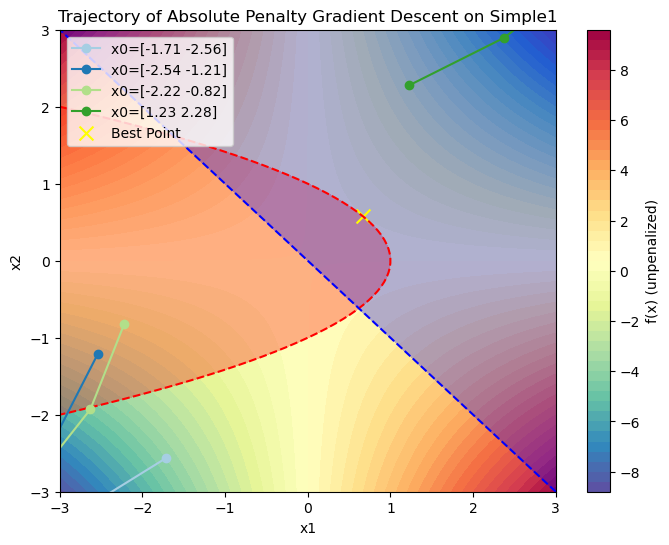

In [83]:
# heatmap of f for Simple1
p = Simple1()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Absolute Penalty Gradient Descent on Simple1')

# constraints
c1 = X1 + X2**2 - 1
c2 = -X1 - X2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple1"]:
    x_hist = x_hists[("Simple1", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple1"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Contour plot with feasible region for Simple2

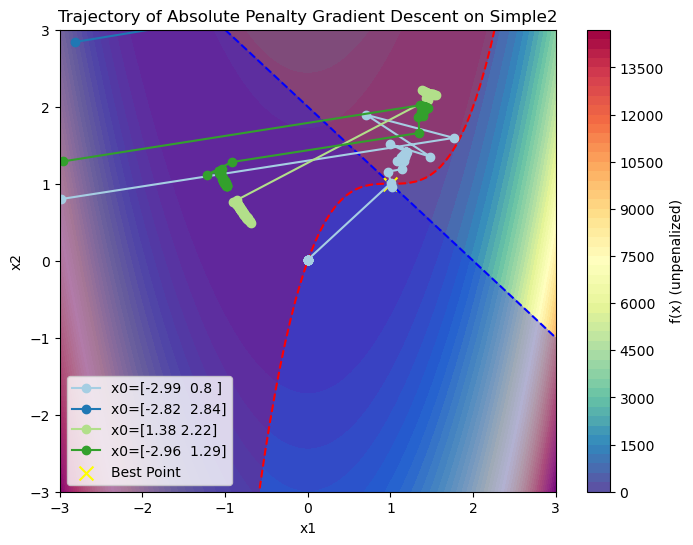

In [84]:
# heatmap of f for Simple2
p = Simple2()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Absolute Penalty Gradient Descent on Simple2')

# constraints
c1 = (X1-1)**3 - X2 + 1
c2 = X1 + X2 -2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple2"]:
    x_hist = x_hists[("Simple2", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple2"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Objective function and maximum constraint violation vs iteration for Simple2

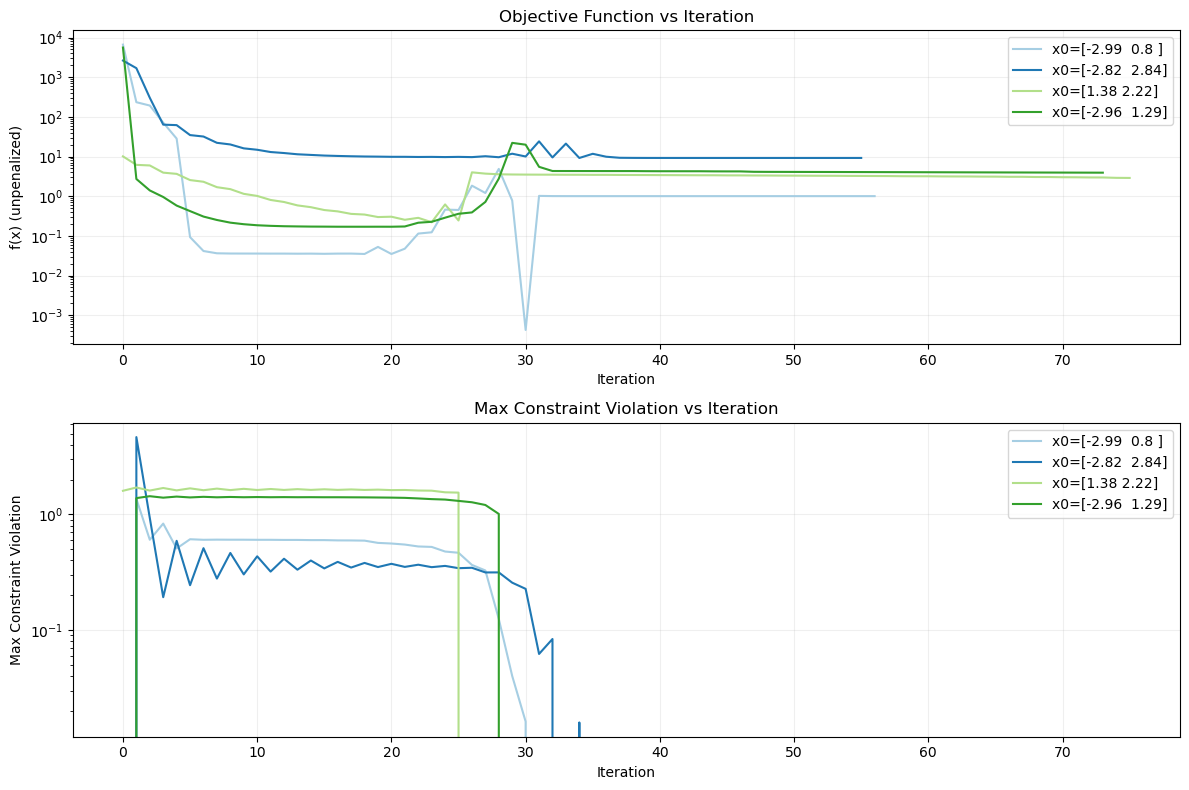

In [85]:
# plot objective function and maximum constraint violation vs iteration for Simple2
plt.figure(figsize=(12, 8))
for i, x0 in enumerate(x0_map["Simple2"]):
    f_history = f_hists[("Simple2", tuple(x0))]

    # plot convergence
    plt.subplot(2,1,1)
    plt.plot(f_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('f(x) (unpenalized)')
    plt.title('Objective Function vs Iteration')
    plt.grid(True, alpha=0.2)
    plt.legend(loc = "best")

    # plot maximum constraint violation
    # get constraint violation history
    c_history = []
    for x in x_hists[("Simple2", tuple(x0))]:
        c1 = (x[0]-1)**3 - x[1] + 1
        c2 = x[0] + x[1] -2
        c_history.append(max(0, max(c1, c2)))
    plt.subplot(2, 1, 2)
    plt.plot(c_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Max Constraint Violation')
    plt.title('Max Constraint Violation vs Iteration')
    plt.legend(loc = "best")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    